# Import Library

In [1]:
!pip install tensorflow

In [16]:
import math
import random
import pickle
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import kagglehub
import time
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    label_ranking_average_precision_score,
    label_ranking_loss,
    coverage_error)
from sklearn.utils import shuffle
from scipy.signal import resample
from sklearn.preprocessing import OneHotEncoder
from keras.models import Model
from keras.layers import (
    LSTM,
    Input,
    Dense,
    Conv1D,
    MaxPooling1D,
    Softmax,
    Add,
    Flatten,
    Activation)
from keras import backend as K
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ModelCheckpoint

np.random.seed(42)

# Exploratory Data Analysis - EDA

## Membaca Data

In [3]:
# Download latest version
path = kagglehub.dataset_download("shayanfazeli/heartbeat")
print("Path to dataset files:", path)

df1 = pd.read_csv(os.path.join(path, "mitbih_train.csv"), header=None)
df2 = pd.read_csv(os.path.join(path, "mitbih_test.csv"), header=None)
df = pd.concat([df1, df2])

Using Colab cache for faster access to the 'heartbeat' dataset.
Path to dataset files: /kaggle/input/heartbeat


In [4]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Visualisasi Sinyal

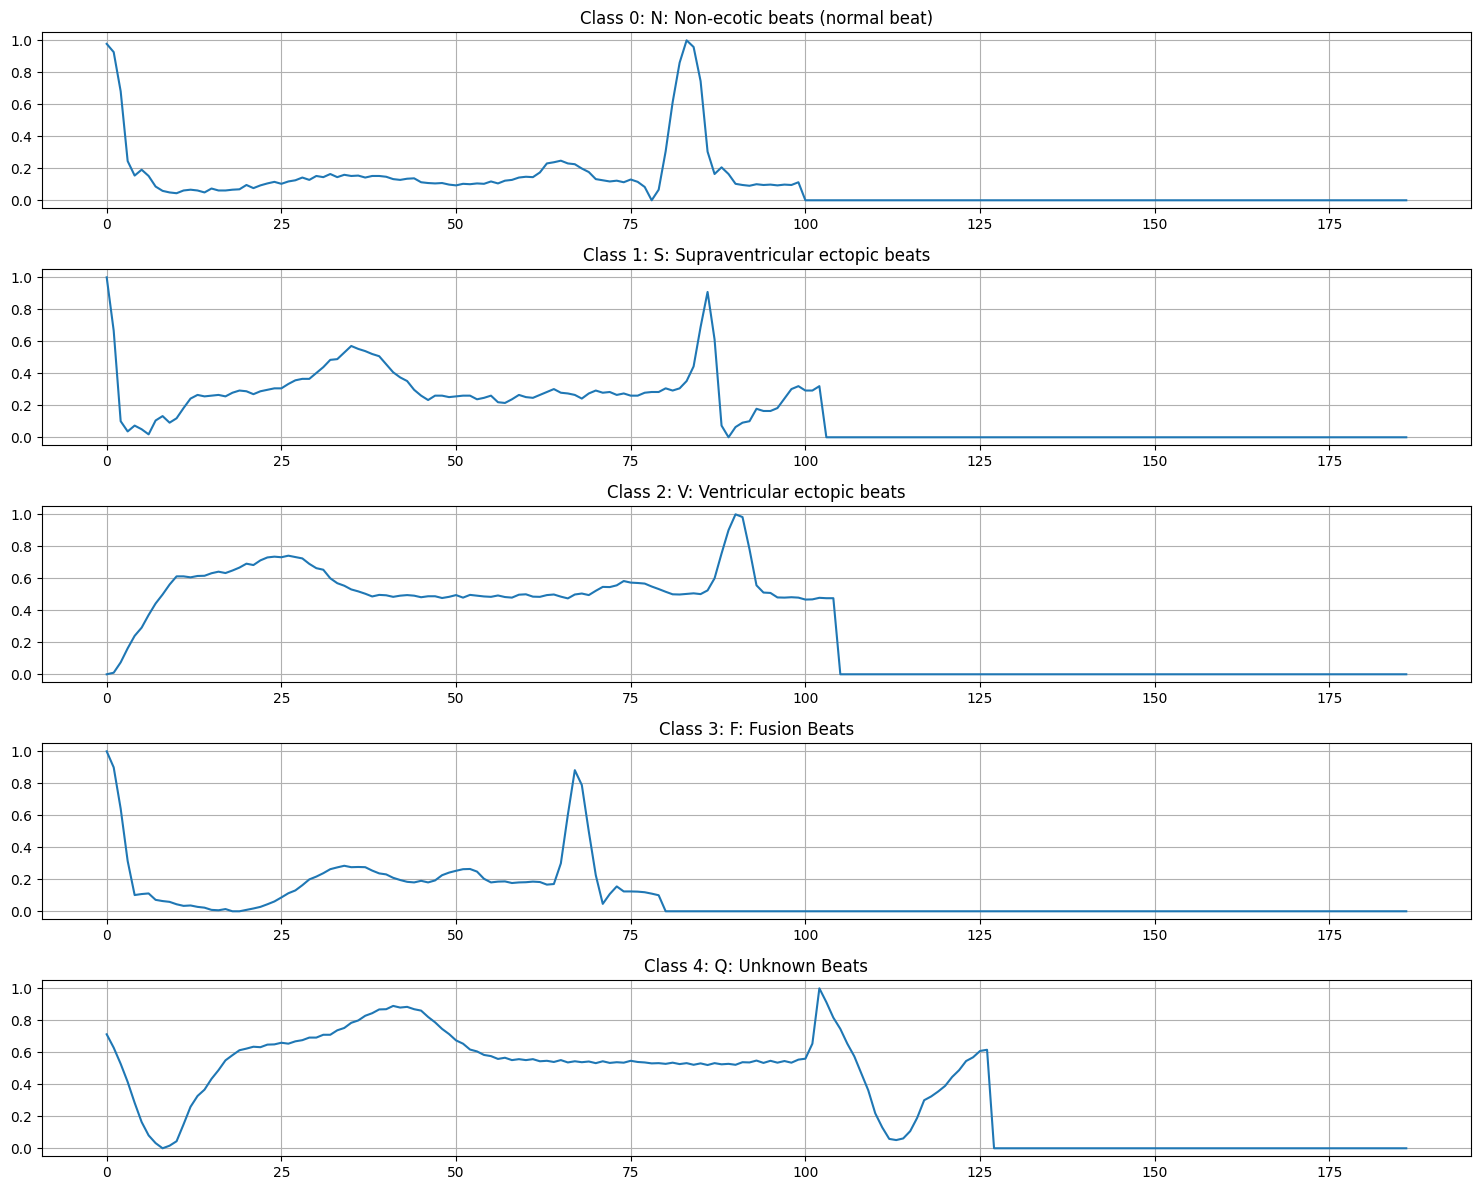

In [5]:
classes = [0, 1, 2, 3, 4]
labels = [
    'N: Non-ecotic beats (normal beat)',
    'S: Supraventricular ectopic beats',
    'V: Ventricular ectopic beats',
    'F: Fusion Beats',
    'Q: Unknown Beats'
]

plt.figure(figsize=(15, 12))

for i, cls in enumerate(classes):
    # Ambil sampel pertama untuk setiap kelas
    sample = df[df[187] == cls].iloc[0, :187]

    plt.subplot(5, 1, i + 1)
    plt.plot(sample)
    plt.title(f"Class {cls}: {labels[i]}")
    plt.grid(True)

plt.tight_layout()
plt.show()

## Analisis Distribusi Kelas

Jumlah sampel per kelas:
187
0.0    90589
1.0     2779
2.0     7236
3.0      803
4.0     8039
Name: count, dtype: int64


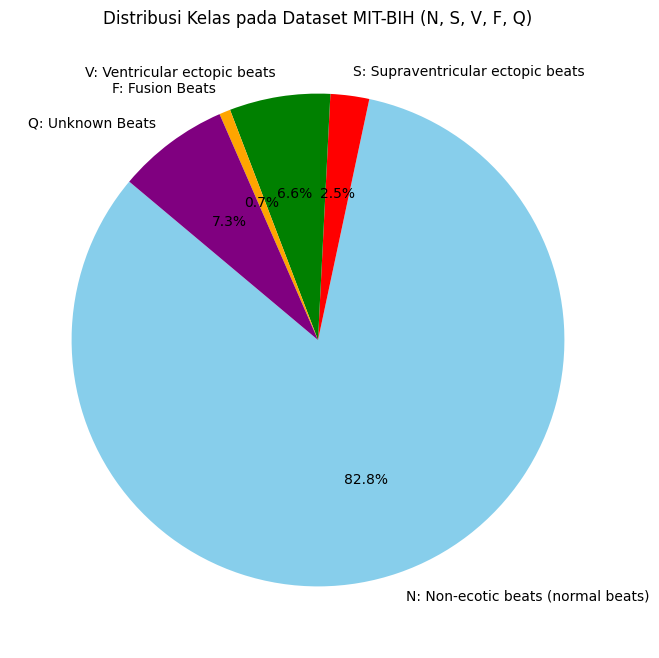

In [6]:
count_classes = df[187].value_counts().sort_index()
print("Jumlah sampel per kelas:")
print(count_classes)

labels_detailed = [
    'N: Non-ecotic beats (normal beats)',
    'S: Supraventricular ectopic beats',
    'V: Ventricular ectopic beats',
    'F: Fusion Beats',
    'Q: Unknown Beats'
]

plt.figure(figsize=(10, 8))
plt.pie(count_classes, labels=labels_detailed, autopct='%1.1f%%', startangle=140, colors=['skyblue', 'red', 'green', 'orange', 'purple'])
plt.title("Distribusi Kelas pada Dataset MIT-BIH (N, S, V, F, Q)")
plt.show()

# Data Preprocessing

## Pemisahan Fitur dan Target

In [7]:
X = df.iloc[:, :187].values
y = df.iloc[:, 187].values

print("Ukuran Fitur (X):", X.shape)
print("Ukuran Target (y):", y.shape)

Ukuran Fitur (X): (109446, 187)
Ukuran Target (y): (109446,)


## Penanganan Data Tidak Seimbang

In [8]:
def resample_dataset(df):
    # Pisahkan setiap kelas
    df_0 = df[df[187] == 0]
    df_1 = df[df[187] == 1]
    df_2 = df[df[187] == 2]
    df_3 = df[df[187] == 3]
    df_4 = df[df[187] == 4]

    # Target jumlah sampel per kelas
    target_samples = 20000

    # Resampling untuk setiap kelas
    df_0_resampled = df_0.sample(n=target_samples, random_state=42) # Undersampling
    df_1_resampled = df_1.sample(n=target_samples, replace=True, random_state=42) # Oversampling
    df_2_resampled = df_2.sample(n=target_samples, replace=True, random_state=42) # Oversampling
    df_3_resampled = df_3.sample(n=target_samples, replace=True, random_state=42) # Oversampling
    df_4_resampled = df_4.sample(n=target_samples, replace=True, random_state=42) # Oversampling

    # Gabungkan kembali
    df_resampled = pd.concat([df_0_resampled, df_1_resampled, df_2_resampled, df_3_resampled, df_4_resampled])
    return df_resampled

# Terapkan resampling
df_balanced = resample_dataset(df)

# Update X dan y dengan data yang sudah seimbang
X_balanced = df_balanced.iloc[:, :187].values
y_balanced = df_balanced.iloc[:, 187].values

print("Distribusi kelas setelah resampling:")
print(df_balanced[187].value_counts().sort_index())
print("\nUkuran X_balanced:", X_balanced.shape)

Distribusi kelas setelah resampling:
187
0.0    20000
1.0    20000
2.0    20000
3.0    20000
4.0    20000
Name: count, dtype: int64

Ukuran X_balanced: (100000, 187)


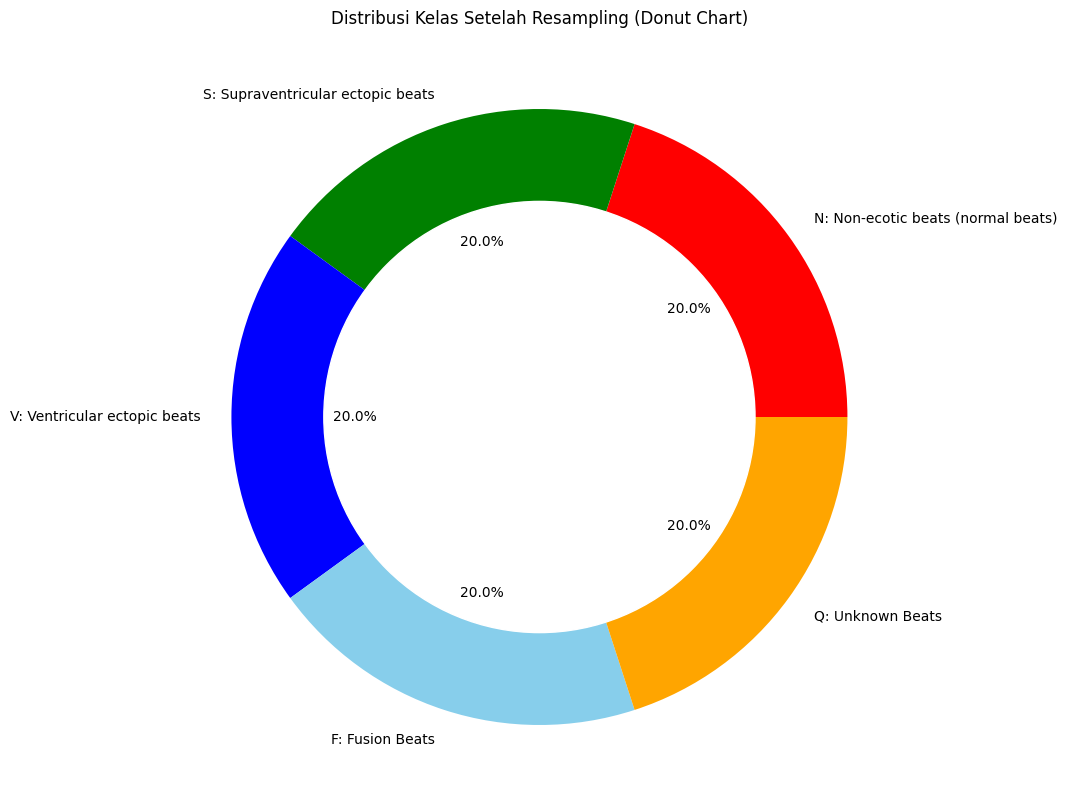

In [9]:
equilibre = df_balanced[187].value_counts()

labels_detailed = [
    'N: Non-ecotic beats (normal beats)',
    'S: Supraventricular ectopic beats',
    'V: Ventricular ectopic beats',
    'F: Fusion Beats',
    'Q: Unknown Beats'
]

plt.figure(figsize=(20,10))
my_circle = plt.Circle((0,0), 0.7, color='white')
plt.pie(equilibre, labels=labels_detailed, colors=['red','green','blue','skyblue','orange'], autopct='%1.1f%%')
p = plt.gcf()
p.gca().add_artist(my_circle)
plt.title("Distribusi Kelas Setelah Resampling (Donut Chart)")
plt.show()

## Reshaping Data

In [10]:
# Reshaping data fitur dari 2D (100000, 187) menjadi 3D (100000, 187, 1)
X_3d = X_balanced.reshape(X_balanced.shape[0], X_balanced.shape[1], 1)

print("Ukuran X_balanced awal:", X_balanced.shape)
print("Ukuran X setelah Reshape (X_3d):", X_3d.shape)

Ukuran X_balanced awal: (100000, 187)
Ukuran X setelah Reshape (X_3d): (100000, 187, 1)


# Pembangunan Model (Modeling)

In [28]:
# 1. One-hot Encoding untuk Target
ohe = OneHotEncoder()
y_balanced_ohe = ohe.fit_transform(y_balanced.reshape(-1, 1)).toarray()

# 2. Definisi Arsitektur Model ResNet-1D
def residual_block(x, filters, kernel_size=3):
    shortcut = x

    x = Conv1D(filters, kernel_size, padding='same')(x)
    x = Activation('relu')(x)

    x = Conv1D(filters, kernel_size, padding='same')(x)

    # Tambahkan shortcut (skip connection)
    x = Add()([x, shortcut])
    x = Activation('relu')(x)
    return x

def build_model(input_shape):
    inp = Input(shape=input_shape)

    # Initial Convolution
    x = Conv1D(64, kernel_size=7, padding='same')(inp)
    x = Activation('relu')(x)

    # Residual Blocks
    x = residual_block(x, 64)
    x = MaxPooling1D(pool_size=2)(x)

    x = residual_block(x, 64)
    x = MaxPooling1D(pool_size=2)(x)

    # Classifier
    x = Flatten()(x)
    x = Dense(32, activation='relu')(x)
    out = Dense(5, activation='softmax')(x)

    resnet1d_model = Model(inputs=inp, outputs=out)
    return resnet1d_model

# Inisialisasi Model
resnet1d_model = build_model(input_shape=(187, 1))
resnet1d_model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 187, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 187, 64)   │        512 │ input_layer_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 187, 64)   │          0 │ conv1d_10[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 187, 64)   │     12,352 │ activation_10[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 187, 64)   │          0 │ conv1d_11[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 187, 64)   │     12,352 │ activation_11[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 187, 64)   │          0 │ conv1d_12[0][0],  │
│                     │                   │            │ activation_10[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_12       │ (None, 187, 64)   │          0 │ add_4[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_4     │ (None, 93, 64)    │          0 │ activation_12[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 93, 64)    │     12,352 │ max_pooling1d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_13       │ (None, 93, 64)    │          0 │ conv1d_13[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_14 (Conv1D)  │ (None, 93, 64)    │     12,352 │ activation_13[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 93, 64)    │          0 │ conv1d_14[0][0],  │
│                     │                   │            │ max_pooling1d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_14       │ (None, 93, 64)    │          0 │ add_5[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_5     │ (None, 46, 64)    │          0 │ activation_14[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 2944)      │          0 │ max_pooling1d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 32)        │     94,240 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 5)         │        165 │ dense_24[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 144,325 (563.77 KB)

 Trainable params: 144,325 (563.77 KB)

 Non-trainable params: 0 (0.00 B)

## Split Data

In [26]:
# Tahap 1: Split 70% Training dan 30% Sisa (Val + Test)
X_train, X_rem, y_train, y_rem = train_test_split(
    X_3d, y_balanced_ohe, test_size=0.3, random_state=42, stratify=y_balanced_ohe
)

# Tahap 2: Split Sisa (30%) menjadi 50% Val dan 50% Test (sehingga masing-masing 15% dari total)
X_val, X_test, y_val, y_test = train_test_split(
    X_rem, y_rem, test_size=0.5, random_state=42, stratify=y_rem
)

print(f"X_train shape: {X_train.shape} (70%)")
print(f"X_val shape:   {X_val.shape} (15%)")
print(f"X_test shape:  {X_test.shape} (15%)")

X_train shape: (70000, 187, 1) (70%)
X_val shape:   (15000, 187, 1) (15%)
X_test shape:  (15000, 187, 1) (15%)


# Training Model (1)

In [31]:
# 1. Kompilasi model terlebih dahulu agar atribut 'optimizer' tersedia
learning_rate1 = 0.01
epochs = 20
batch_size = 32

resnet1d_model.compile(
    optimizer=Adam(learning_rate=learning_rate1),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

# 2. Konfigurasi Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)]

# 3. Jalankan Pelatihan
history1 = resnet1d_model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1)

Epoch 1/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9371 - loss: 0.1752
Epoch 1: val_accuracy improved from None to 0.95467, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 130s 56ms/step - accuracy: 0.9424 - loss: 0.1630 - val_accuracy: 0.9547 - val_loss: 0.1343
Epoch 2/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9522 - loss: 0.1366
Epoch 2: val_accuracy did not improve from 0.95467
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 120s 55ms/step - accuracy: 0.9526 - loss: 0.1371 - val_accuracy: 0.9462 - val_loss: 0.1608
Epoch 3/20
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9568 - loss: 0.1276
Epoch 3: val_accuracy improved from 0.95467 to 0.96160, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 141s 54ms/step - accuracy: 0.9578 - loss: 0.1228 - val_accuracy: 0.9616 - val_loss: 0.1166
Epoch 4/20
2188/2188 ━━━━━━━━━━━━━━━━

# Evaluasi Metrik (1)

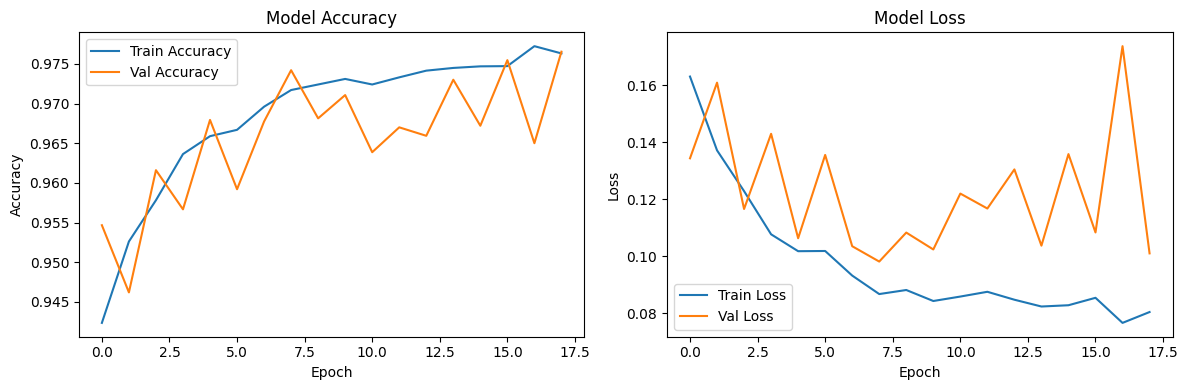

In [32]:
# Visualisasi Hasil Pelatihan
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history1.history['accuracy'], label='Train Accuracy')
plt.plot(history1.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history1.history['loss'], label='Train Loss')
plt.plot(history1.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [36]:
# Evaluasi Model pada Test Set
# Menghitung waktu mulai prediksi
start_time = time.time()
y_pred_ohe = resnet1d_model.predict(X_test)
end_time = time.time()

# Hitung total waktu dan rata-rata per sampel
total_time1 = end_time - start_time
y_pred_labels = np.argmax(y_pred_ohe, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# 1. Hasil Evaluasi Dasar
loss1, accuracy1 = resnet1d_model.evaluate(X_test, y_test, verbose=0)
print(f"Learning Rate: {learning_rate1}")
print(f"Epochs: {epochs}")
print(f"Batch size: {batch_size}")

print(f"Test Loss: {loss1:.4f}")
print(f"Test Accuracy: {accuracy1:.4f}")
print(f"Total Prediction Time: {total_time1:.2f} detik")

# 2. Classification Report dengan 3 angka di belakang koma
print("\nClassification Report:")
target_names = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Unknown']
print(classification_report(y_true_labels, y_pred_labels, target_names=target_names, digits=3))

469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step
Learning Rate: 0.01
Epochs: 20
Batch size: 32
Test Loss: 0.0957
Test Accuracy: 0.9723
Total Prediction Time: 9.91 detik

Classification Report:
                  precision    recall  f1-score   support

          Normal      0.947     0.944     0.946      3000
Supraventricular      0.970     0.964     0.967      3000
     Ventricular      0.984     0.972     0.978      3000
          Fusion      0.971     0.988     0.980      3000
         Unknown      0.988     0.994     0.991      3000

        accuracy                          0.972     15000
       macro avg      0.972     0.972     0.972     15000
    weighted avg      0.972     0.972     0.972     15000



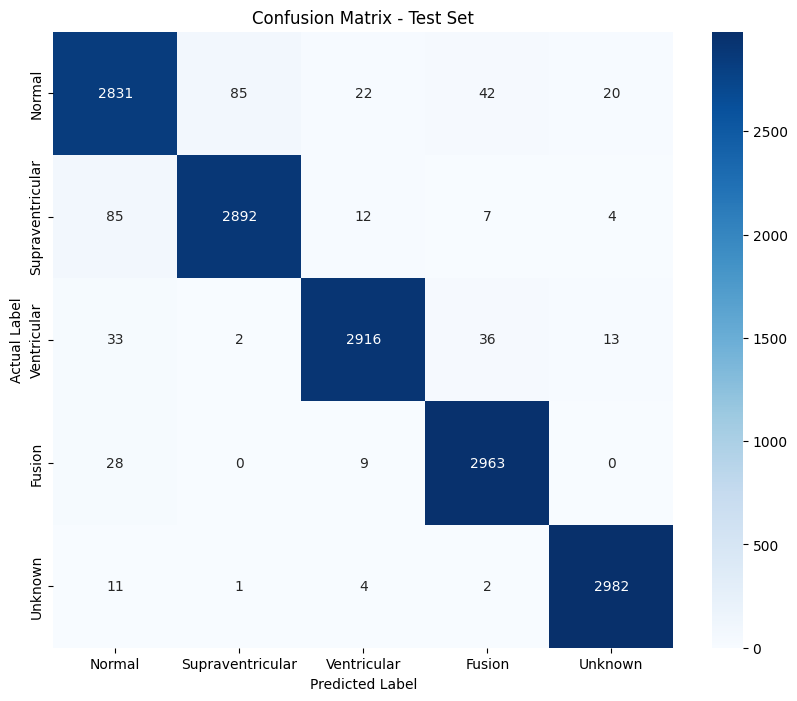

In [34]:
# Confusion Matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

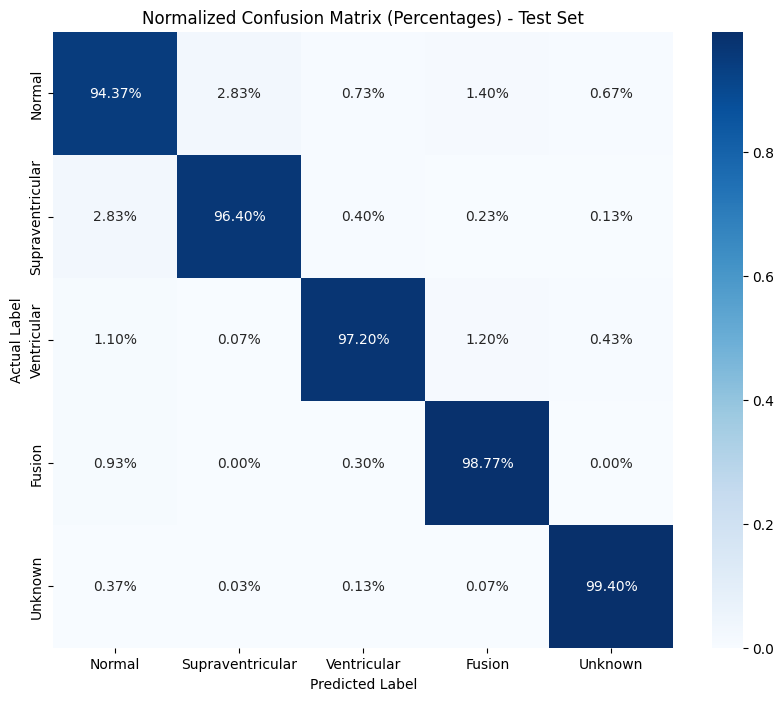

In [35]:
# Confusion Matrix dengan Persentase (Normalized)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Normalized Confusion Matrix (Percentages) - Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Training Model (2)

In [37]:
# 1. Kompilasi model terlebih dahulu agar atribut 'optimizer' tersedia
learning_rate2 = 0.005
epochs = 20
batch_size = 32

resnet1d_model.compile(
    optimizer=Adam(learning_rate=learning_rate2),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

# 2. Konfigurasi Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)]

# 3. Jalankan Pelatihan
history2 = resnet1d_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1)

Epoch 1/20
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9829 - loss: 0.0532
Epoch 1: val_accuracy improved from None to 0.97813, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 136s 60ms/step - accuracy: 0.9838 - loss: 0.0500 - val_accuracy: 0.9781 - val_loss: 0.0874
Epoch 2/20
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9859 - loss: 0.0423
Epoch 2: val_accuracy improved from 0.97813 to 0.98093, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 122s 56ms/step - accuracy: 0.9858 - loss: 0.0433 - val_accuracy: 0.9809 - val_loss: 0.0801
Epoch 3/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9882 - loss: 0.0374
Epoch 3: val_accuracy did not improve from 0.98093
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 139s 54ms/step - accuracy: 0.9877 - loss: 0.0377 - val_accuracy: 0.9786 - val_loss: 0.0805
Epoch 4/20
2187/2188 ━━━━━━━━━━━━━━━━

# Evaluasi Metrik (2)

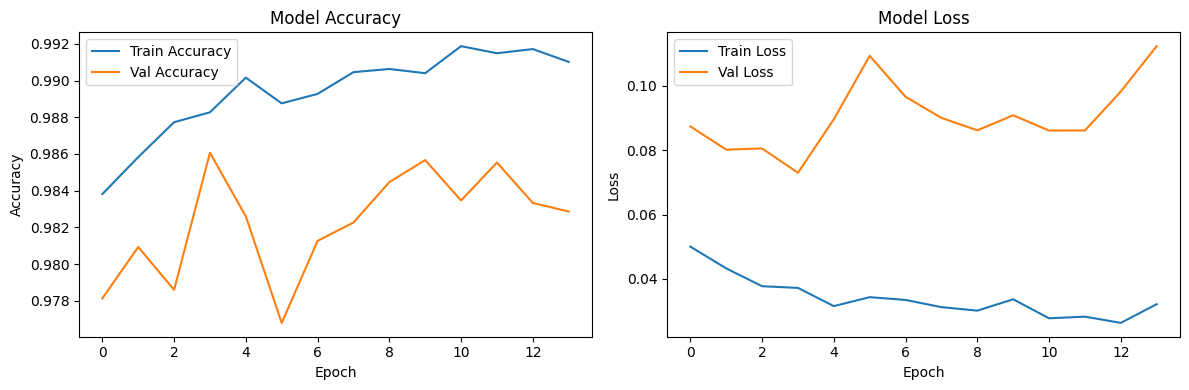

In [38]:
# Visualisasi Hasil Pelatihan
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history2.history['accuracy'], label='Train Accuracy')
plt.plot(history2.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [40]:
# Evaluasi Model pada Test Set
# Menghitung waktu mulai prediksi
start_time = time.time()
y_pred_ohe = resnet1d_model.predict(X_test)
end_time = time.time()

# Hitung total waktu dan rata-rata per sampel
total_time2 = end_time - start_time
y_pred_labels = np.argmax(y_pred_ohe, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# 1. Hasil Evaluasi Dasar
loss2, accuracy2 = resnet1d_model.evaluate(X_test, y_test, verbose=0)
print(f"Learning Rate: {learning_rate2}")
print(f"Epochs: {epochs}")
print(f"Batch size: {batch_size}")

print(f"Test Loss: {loss2:.4f}")
print(f"Test Accuracy: {accuracy2:.4f}")
print(f"Total Prediction Time: {total_time2:.2f} detik")

# 2. Classification Report dengan 3 angka di belakang koma
print("\nClassification Report:")
target_names = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Unknown']
print(classification_report(y_true_labels, y_pred_labels, target_names=target_names, digits=3))

469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step
Learning Rate: 0.005
Epochs: 20
Batch size: 32
Test Loss: 0.0686
Test Accuracy: 0.9855
Total Prediction Time: 10.46 detik

Classification Report:
                  precision    recall  f1-score   support

          Normal      0.982     0.959     0.971      3000
Supraventricular      0.977     0.989     0.983      3000
     Ventricular      0.991     0.984     0.988      3000
          Fusion      0.983     0.999     0.991      3000
         Unknown      0.994     0.996     0.995      3000

        accuracy                          0.985     15000
       macro avg      0.985     0.985     0.985     15000
    weighted avg      0.985     0.985     0.985     15000



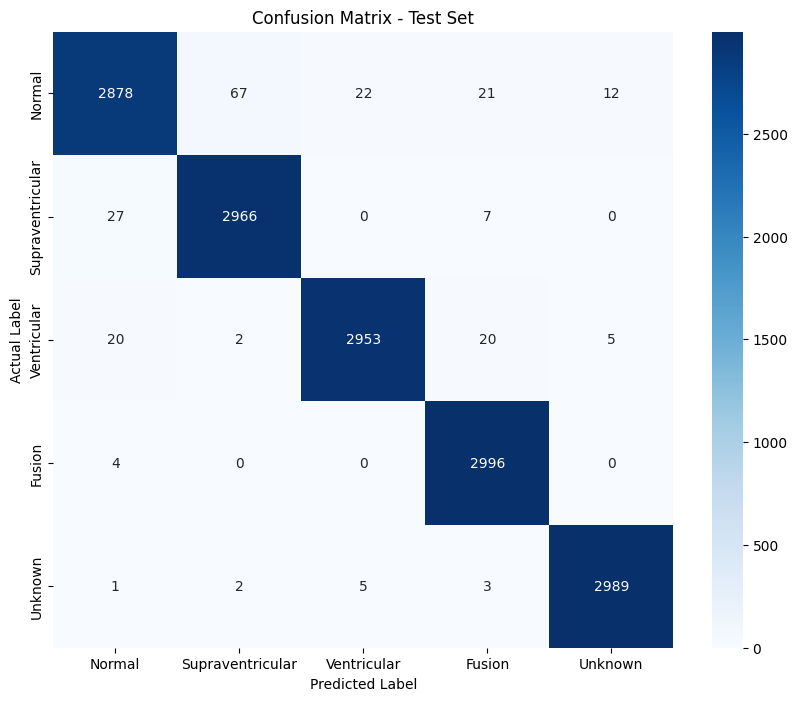

In [41]:
# Confusion Matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

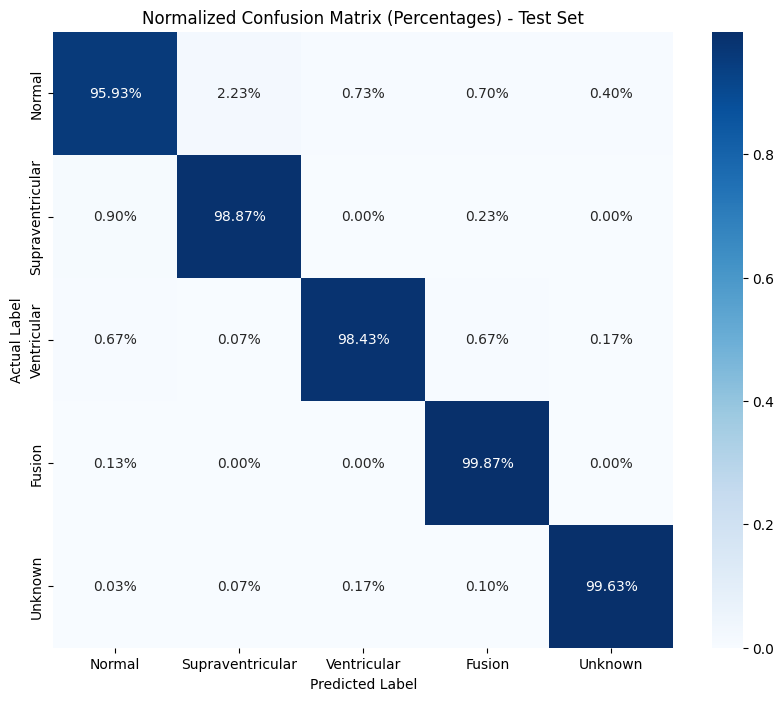

In [42]:
# Confusion Matrix dengan Persentase (Normalized)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Normalized Confusion Matrix (Percentages) - Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Training Model (3)


In [43]:
# 1. Kompilasi model terlebih dahulu agar atribut 'optimizer' tersedia
learning_rate3 = 0.001
epochs = 20
batch_size = 32

resnet1d_model.compile(
    optimizer=Adam(learning_rate=learning_rate3),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

# 2. Konfigurasi Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)]

# 3. Jalankan Pelatihan
history = resnet1d_model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1)

Epoch 1/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9945 - loss: 0.0188
Epoch 1: val_accuracy improved from None to 0.98900, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 127s 56ms/step - accuracy: 0.9951 - loss: 0.0169 - val_accuracy: 0.9890 - val_loss: 0.0648
Epoch 2/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9959 - loss: 0.0135
Epoch 2: val_accuracy improved from 0.98900 to 0.99033, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 144s 57ms/step - accuracy: 0.9965 - loss: 0.0125 - val_accuracy: 0.9903 - val_loss: 0.0645
Epoch 3/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9971 - loss: 0.0101
Epoch 3: val_accuracy did not improve from 0.99033
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 121s 55ms/step - accuracy: 0.9970 - loss: 0.0110 - val_accuracy: 0.9896 - val_loss: 0.0703
Epoch 4/20
2187/2188 ━━━━━━━━━━━━━━━━

# Evaluasi Metrik (3)


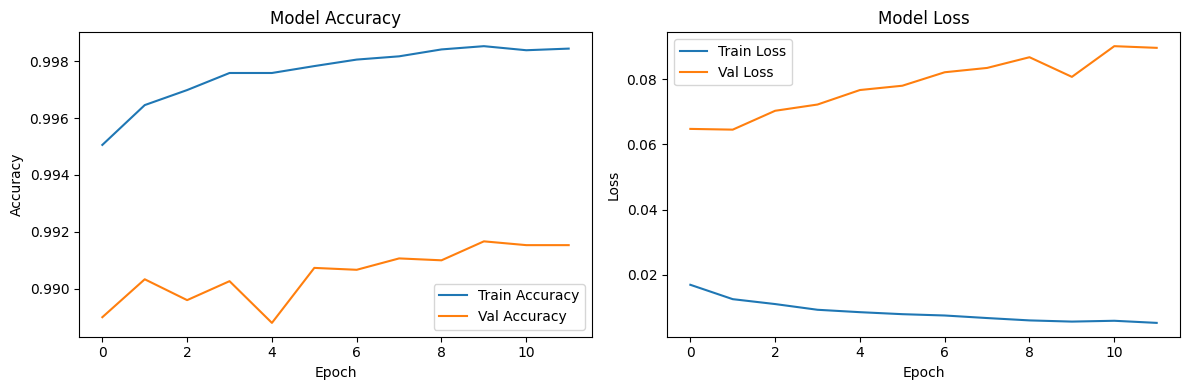

In [44]:
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [46]:
# Evaluasi Model pada Test Set
# Menghitung waktu mulai prediksi
start_time = time.time()
y_pred_ohe = resnet1d_model.predict(X_test)
end_time = time.time()

# Hitung total waktu dan rata-rata per sampel
total_time3 = end_time - start_time
y_pred_labels = np.argmax(y_pred_ohe, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# 1. Hasil Evaluasi Dasar
loss3, accuracy3 = resnet1d_model.evaluate(X_test, y_test, verbose=0)
print(f"Learning Rate: {learning_rate3}")
print(f"Epochs: {epochs}")
print(f"Batch size: {batch_size}")

print(f"Test Loss: {loss3:.4f}")
print(f"Test Accuracy: {accuracy3:.4f}")
print(f"Total Prediction Time: {total_time3:.2f} detik")

# 2. Classification Report dengan 3 angka di belakang koma
print("\nClassification Report:")
target_names = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Unknown']
print(classification_report(y_true_labels, y_pred_labels, target_names=target_names, digits=3))

469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step
Learning Rate: 0.001
Epochs: 20
Batch size: 32
Test Loss: 0.0578
Test Accuracy: 0.9899
Total Prediction Time: 12.77 detik

Classification Report:
                  precision    recall  f1-score   support

          Normal      0.991     0.968     0.979      3000
Supraventricular      0.985     0.996     0.991      3000
     Ventricular      0.989     0.988     0.989      3000
          Fusion      0.989     1.000     0.994      3000
         Unknown      0.995     0.997     0.996      3000

        accuracy                          0.990     15000
       macro avg      0.990     0.990     0.990     15000
    weighted avg      0.990     0.990     0.990     15000



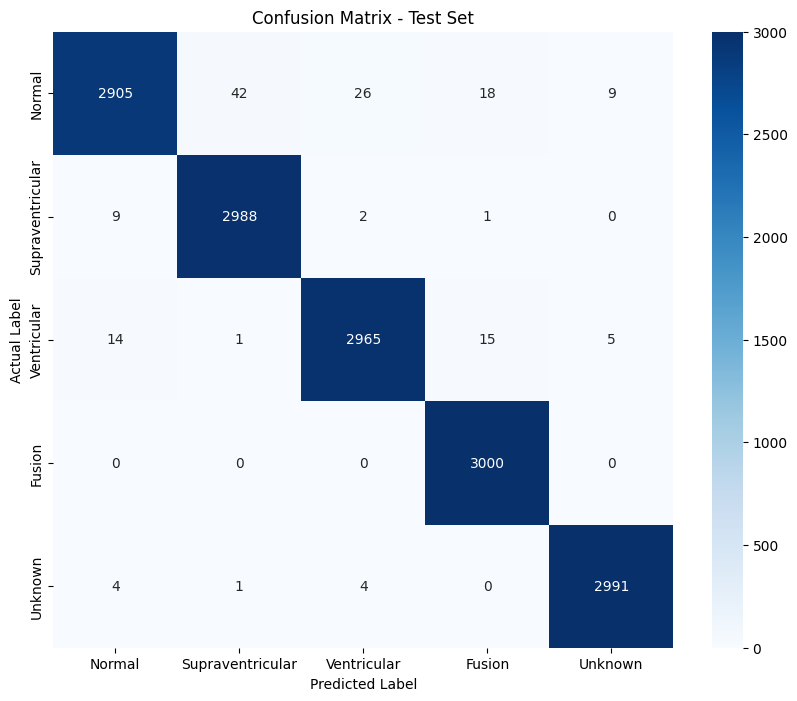

In [47]:
# Confusion Matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

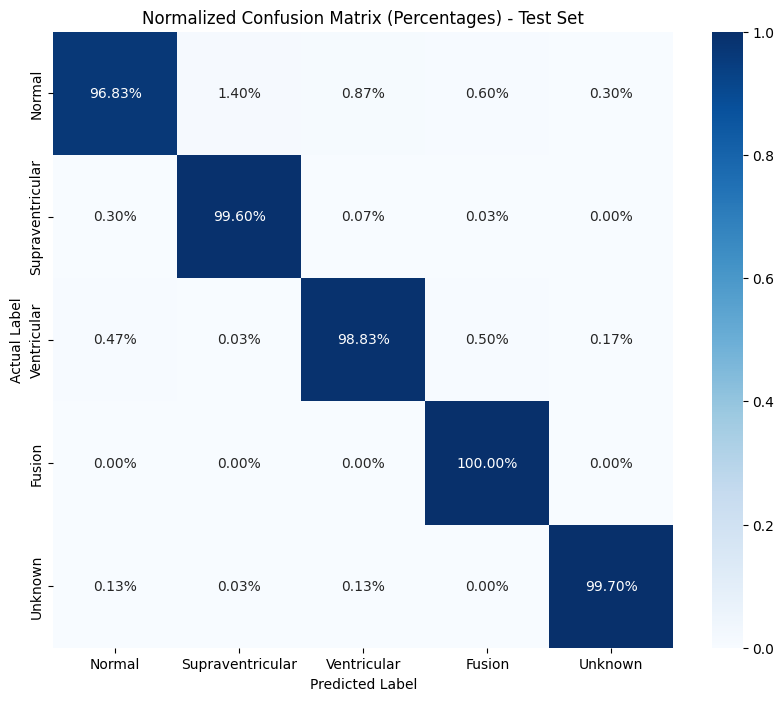

In [48]:
# Confusion Matrix dengan Persentase (Normalized)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Normalized Confusion Matrix (Percentages) - Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Training Model (4)

In [49]:
# 1. Kompilasi model terlebih dahulu agar atribut 'optimizer' tersedia
learning_rate4 = 0.0005
epochs = 20
batch_size = 32

resnet1d_model.compile(
    optimizer=Adam(learning_rate=learning_rate4),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

# 2. Konfigurasi Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)]

# 3. Jalankan Pelatihan
history = resnet1d_model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1)

Epoch 1/20
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.9972 - loss: 0.0103
Epoch 1: val_accuracy improved from None to 0.99100, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 183s 80ms/step - accuracy: 0.9974 - loss: 0.0101 - val_accuracy: 0.9910 - val_loss: 0.0659
Epoch 2/20
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9981 - loss: 0.0077
Epoch 2: val_accuracy improved from 0.99100 to 0.99147, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 123s 56ms/step - accuracy: 0.9977 - loss: 0.0089 - val_accuracy: 0.9915 - val_loss: 0.0691
Epoch 3/20
2187/2188 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9982 - loss: 0.0078
Epoch 3: val_accuracy did not improve from 0.99147
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 125s 57ms/step - accuracy: 0.9980 - loss: 0.0080 - val_accuracy: 0.9913 - val_loss: 0.0705
Epoch 4/20
2188/2188 ━━━━━━━━━━━━━━━━

# Evaluasi Metrik (4)

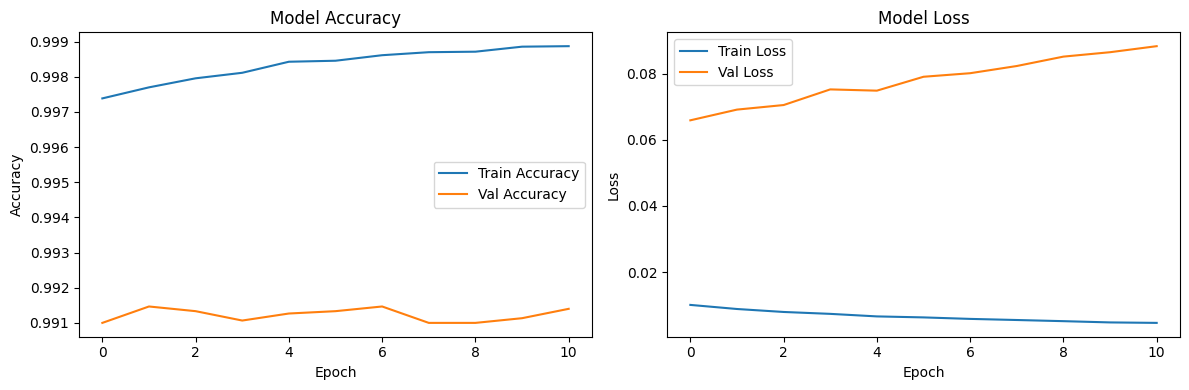

In [51]:
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [53]:
# Evaluasi Model pada Test Set
# Menghitung waktu mulai prediksi
start_time = time.time()
y_pred_ohe = resnet1d_model.predict(X_test)
end_time = time.time()

# Hitung total waktu dan rata-rata per sampel
total_time4 = end_time - start_time
y_pred_labels = np.argmax(y_pred_ohe, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# 1. Hasil Evaluasi Dasar
loss4, accuracy4 = resnet1d_model.evaluate(X_test, y_test, verbose=0)
print(f"Learning Rate: {learning_rate4}")
print(f"Epochs: {epochs}")
print(f"Batch size: {batch_size}")

print(f"Test Loss: {loss4:.4f}")
print(f"Test Accuracy: {accuracy4:.4f}")
print(f"Total Prediction Time: {total_time4:.2f} detik")

# 2. Classification Report dengan 3 angka di belakang koma
print("\nClassification Report:")
target_names = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Unknown']
print(classification_report(y_true_labels, y_pred_labels, target_names=target_names, digits=3))

469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step
Learning Rate: 0.0005
Epochs: 20
Batch size: 32
Test Loss: 0.0573
Test Accuracy: 0.9905
Total Prediction Time: 10.90 detik

Classification Report:
                  precision    recall  f1-score   support

          Normal      0.993     0.968     0.980      3000
Supraventricular      0.984     0.998     0.991      3000
     Ventricular      0.991     0.989     0.990      3000
          Fusion      0.989     1.000     0.995      3000
         Unknown      0.995     0.997     0.996      3000

        accuracy                          0.991     15000
       macro avg      0.991     0.991     0.991     15000
    weighted avg      0.991     0.991     0.991     15000



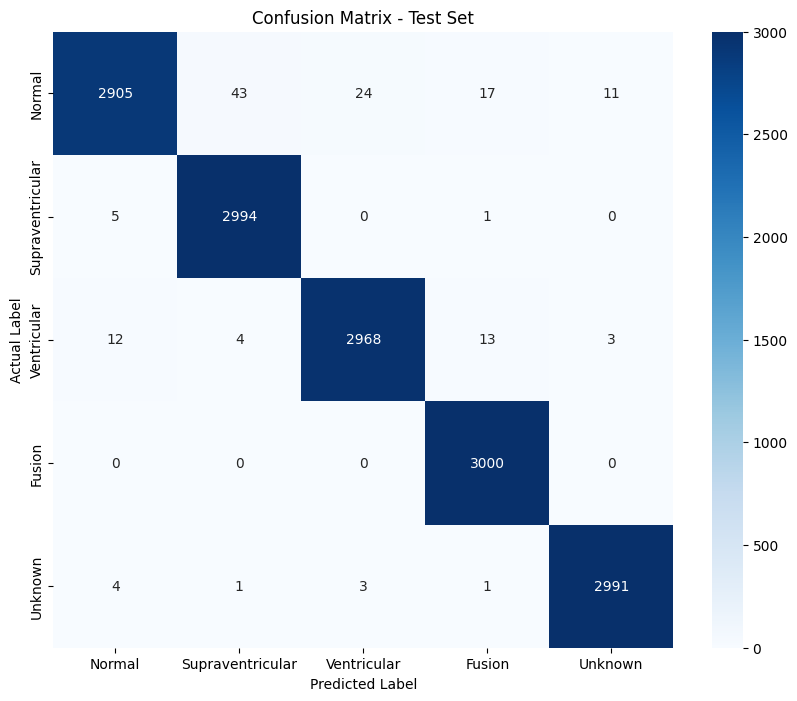

In [54]:
# Confusion Matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

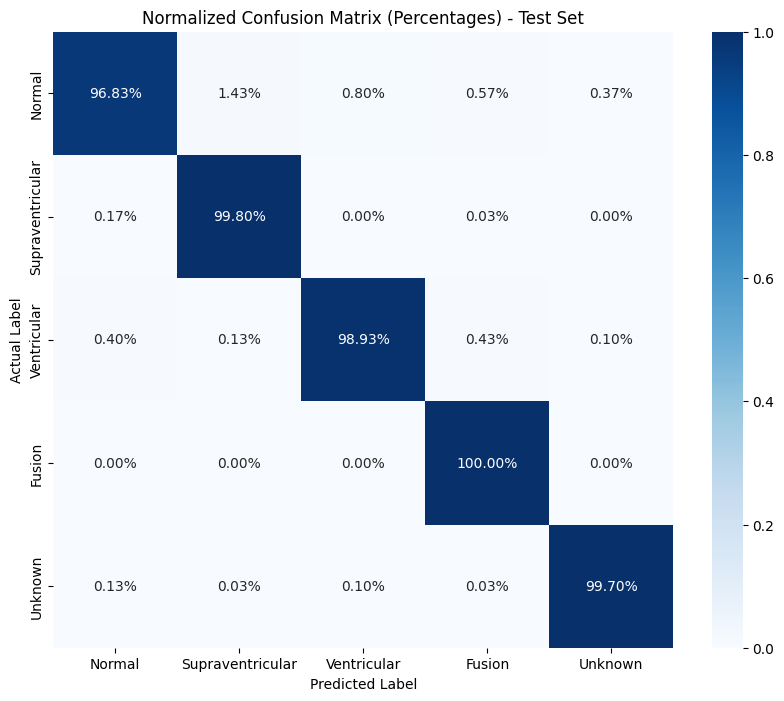

In [55]:
# Confusion Matrix dengan Persentase (Normalized)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Normalized Confusion Matrix (Percentages) - Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [58]:
# Membuat data untuk tabel ringkasan
data = {
  'Learning Rate': [learning_rate1, learning_rate2, learning_rate3, learning_rate4],
  'Epochs': [epochs, epochs, epochs, epochs],
  'Batch Size': [batch_size, batch_size, batch_size, batch_size],
  'Test Loss': [f"{loss1:.4f}", f"{loss2:.4f}", f"{loss3:.4f}", f"{loss4:.4f}"],
  'Test Accuracy': [f"{accuracy1*100:.2f}%", f"{accuracy2*100:.2f}%", f"{accuracy3*100:.2f}%", f"{accuracy4*100:.2f}%"],
  'Eval Runtime (Detik)': [total_time1, total_time2, total_time3, total_time4]
}

# Membuat DataFrame
df_summary = pd.DataFrame(data)

# Menampilkan tabel
print("Summary Statistik Performa Model:")
display(df_summary)

Summary Statistik Performa Model:


,Learning Rate,Epochs,Batch Size,Test Loss,Test Accuracy,Eval Runtime (Detik)
0,0.0100,20,32,0.0957,97.23%,9.909966
1,0.0050,20,32,0.0686,98.55%,10.463634
2,0.0010,20,32,0.0578,98.99%,12.766562
3,0.0005,20,32,0.0573,99.05%,10.897777


# Penyimpanan dan Deployment

In [60]:
# 1. Simpan Model Utama
resnet1d_model.save('mitbih_cnn_model.keras')
print("Model berhasil disimpan sebagai 'mitbih_cnn_model.keras'")

# 2. Simpan OneHotEncoder (Sangat penting untuk tahap inferensi nanti)
with open('encoder.pkl', 'wb') as f:
    pickle.dump(ohe, f)
print("Encoder berhasil disimpan sebagai 'encoder.pkl'")

Model berhasil disimpan sebagai 'mitbih_cnn_model.keras'
Encoder berhasil disimpan sebagai 'encoder.pkl'
